# Notebook 03 – Preprocesamiento de la Matriz de Intensidades

**Objetivo:** Construir la matriz de intensidades a partir de los **picos limpios con Hit 1: Match Factor ≥ 700**, independientemente de si tienen coincidencia en la base de datos.

**Criterio de entrada:**
- Fuente: `peaks_clean.csv` (372 picos limpios del notebook 01)
- Filtro: `Hit 1: Match Factor ≥ 700` → **279 picos**

**La base de datos solo se usará después para interpretación, no para decidir qué picos entran en el análisis.**

**Pasos:** construcción de la matriz → tratamiento de ceros → log₂ → detección de outliers → escalado.

## Celda 1 — Importaciones y rutas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

# Rutas
DATA_PROC = Path('../data/processed')
FIGS = Path('../results/figures')
FIGS.mkdir(parents=True, exist_ok=True)

print('✓ Librerías importadas correctamente')

✓ Librerías importadas correctamente


## Celda 3 — Carga de datos

In [2]:
peaks_clean = pd.read_csv(DATA_PROC / 'peaks_clean.csv')

exp_cols_sorted = sorted(
    [col for col in peaks_clean.columns if col.startswith('Exp_')],
    key=lambda x: int(x.split('_')[1].split('.')[0])
)

print('=' * 65)
print('DATOS CARGADOS')
print('=' * 65)
print(f'peaks_clean shape : {peaks_clean.shape}')
print(f'Experimentos      : {len(exp_cols_sorted)}')
print(f'\nDistribución Hit 1: Match Factor:')
print(peaks_clean['Hit 1: Match Factor'].describe().round(1).to_string())

DATOS CARGADOS
peaks_clean shape : (372, 32)
Experimentos      : 17

Distribución Hit 1: Match Factor:
count    372.0
mean     788.9
std      122.8
min      408.0
25%      699.8
50%      811.5
75%      891.5
max      972.0


## Celda 5 — Filtrado por Match Factor y construcción de la matriz

Se seleccionan los picos con **Hit 1: Match Factor ≥ 700** como criterio de calidad espectral.  
La matriz resultante tiene una fila por pico (no por compuesto único) y una columna por experimento.

In [11]:
# Filtrar por Hit 1: Match Factor >= 700
THRESHOLD = 700
peaks_filtered = peaks_clean[peaks_clean['Hit 1: Match Factor'] >= THRESHOLD].copy()
peaks_filtered = peaks_filtered.reset_index(drop=True)

# Matriz de intensidades: filas = picos, columnas = experimentos
X = peaks_filtered[exp_cols_sorted].copy().astype(float)
X.index = peaks_filtered['Compound Name']

n_zeros   = (X == 0).values.sum()
pct_zeros = n_zeros / X.size * 100

print('=' * 65)
print('MATRIZ DE INTENSIDADES')
print('=' * 65)
print(f'\nPicos totales en peaks_clean    : {len(peaks_clean)}')
print(f'Picos con Match Factor ≥ {THRESHOLD}  : {len(peaks_filtered)}')
print(f'Picos descartados               : {len(peaks_clean) - len(peaks_filtered)}')
print(f'\nShape (picos × experimentos)    : {X.shape}')
print(f'Valores cero                    : {n_zeros} / {X.size} ({pct_zeros:.1f}%)')

MATRIZ DE INTENSIDADES

Picos totales en peaks_clean    : 372
Picos con Match Factor ≥ 700  : 279
Picos descartados               : 93

Shape (picos × experimentos)    : (279, 17)
Valores cero                    : 211 / 4743 (4.4%)


## Celda 7 — Tratamiento de ceros

En este dataset, **un valor 0 significa que el metabolito no fue detectado bajo las condiciones de ese experimento concreto**. Dado que los 17 experimentos corresponden a condiciones experimentales distintas, la ausencia de un metabolito en un experimento es en sí misma información biológica relevante.

Los ceros se mantienen y tras aplicar `log2(x + 1)` se convierten en 0, que el análisis posterior interpreta correctamente como "no detectado".

In [4]:
# Los ceros se conservan como señal biológica real:
# 0 = metabolito no detectado bajo las condiciones de ese experimento.
# No se realiza ninguna imputación.

n_zeros = (X == 0).values.sum()
pct_zeros = n_zeros / X.size * 100

print(f'Valores cero en la matriz: {n_zeros} / {X.size} ({pct_zeros:.1f}%)')
print(f'Distribución de ceros por experimento:')
for col in exp_cols_sorted:
    z = (X[col] == 0).sum()
    print(f'  {col.replace(".CDF",""):<8}  {z:2d} metabolitos no detectados')
print(f'\n✓ Ceros conservados como "no detectado en esas condiciones". Sin imputación.')

Valores cero en la matriz: 211 / 4743 (4.4%)
Distribución de ceros por experimento:
  Exp_1     21 metabolitos no detectados
  Exp_2     18 metabolitos no detectados
  Exp_3      8 metabolitos no detectados
  Exp_4     15 metabolitos no detectados
  Exp_5      2 metabolitos no detectados
  Exp_6      2 metabolitos no detectados
  Exp_7      2 metabolitos no detectados
  Exp_8      6 metabolitos no detectados
  Exp_9     105 metabolitos no detectados
  Exp_10    10 metabolitos no detectados
  Exp_11    12 metabolitos no detectados
  Exp_12     1 metabolitos no detectados
  Exp_13     2 metabolitos no detectados
  Exp_14     2 metabolitos no detectados
  Exp_15     1 metabolitos no detectados
  Exp_16     2 metabolitos no detectados
  Exp_17     2 metabolitos no detectados

✓ Ceros conservados como "no detectado en esas condiciones". Sin imputación.


## Celda 9 — Transformación log2

Las intensidades GC-MS tienen distribución muy sesgada (algunos compuestos con intensidades 1000× mayores que otros).  

**log2(x + 1)** es la transformación estándar en metabolómica porque:
- Comprime el rango dinámico amplio de GC-MS.
- Hace las distribuciones más simétricas y aproximadamente normales.
- Facilita la interpretación: una diferencia de 1 unidad en log2 = cambio de 2× en intensidad.

In [5]:
# Estadísticas antes de la transformación
mean_before = X.values.mean()
std_before  = X.values.std()
print('Antes de log2:')
print(f'  Media          : {mean_before:.4e}')
print(f'  Desv. estándar : {std_before:.4e}')

# Transformación log2(x + 1)
# Los 0 → log2(0+1) = 0, conservando la información de "no detectado"
X_log2 = np.log2(X + 1)

mean_after = X_log2.values.mean()
std_after  = X_log2.values.std()
print(f'\nDespués de log2(x + 1):')
print(f'  Media          : {mean_after:.4f}')
print(f'  Desv. estándar : {std_after:.4f}')
print(f'\nNota: los ceros permanecen como 0 tras log2(0+1) = 0.')
print(f'✓ Transformación log2 aplicada. Shape: {X_log2.shape}')

Antes de log2:
  Media          : 2.0472e+05
  Desv. estándar : 2.2628e+06

Después de log2(x + 1):
  Media          : 12.9645
  Desv. estándar : 4.1520

Nota: los ceros permanecen como 0 tras log2(0+1) = 0.
✓ Transformación log2 aplicada. Shape: (279, 17)


## Celda 11 — Detección de experimentos atípicos (Isolation Forest)

Se aplica **Isolation Forest** sobre la matriz transpuesta (17 experimentos × 64 compuestos) para detectar experimentos cuyo perfil metabolómico global difiere del resto.  
- `contamination=0.05` → se espera como máximo ~5% de experimentos atípicos.
- Los experimentos flagged **no se eliminan** pero se documentan para considerarlos en análisis posteriores.

In [6]:
# Isolation Forest sobre experimentos (transponer la matriz)
# Entrada: 17 experimentos × 64 compuestos
X_T = X_log2.T  # shape: (17, 64)

iso_forest = IsolationForest(contamination=0.05, random_state=42)
outlier_labels = iso_forest.fit_predict(X_T.values)
# IsolationForest: +1 = inlier, -1 = outlier

outlier_mask = outlier_labels == -1
outlier_experiments = X_T.index[outlier_mask].tolist()
inlier_experiments  = X_T.index[~outlier_mask].tolist()

print('=' * 65)
print('DETECCIÓN DE EXPERIMENTOS ATÍPICOS (Isolation Forest)')
print('=' * 65)
print(f'\nExperimentos analizados : {len(X_T)}')
print(f'Experimentos normales   : {sum(~outlier_mask)}')
print(f'Experimentos atípicos   : {sum(outlier_mask)}')

if outlier_experiments:
    print(f'\n⚠ Experimentos flagged como atípicos:')
    for exp in outlier_experiments:
        score = iso_forest.decision_function(X_T.loc[[exp]].values)[0]
        print(f'   {exp}  (anomaly score: {score:.4f})')
else:
    print('\n✓ Ningún experimento detectado como atípico.')

print(f'\nNOTA: Los experimentos atípicos se mantienen en el análisis.')
print(f'      Considerar su impacto en análisis multivariante posteriores.')

DETECCIÓN DE EXPERIMENTOS ATÍPICOS (Isolation Forest)

Experimentos analizados : 17
Experimentos normales   : 16
Experimentos atípicos   : 1

⚠ Experimentos flagged como atípicos:
   Exp_9.CDF  (anomaly score: -0.1931)

NOTA: Los experimentos atípicos se mantienen en el análisis.
      Considerar su impacto en análisis multivariante posteriores.


El valor negativo de Exp_9 no indica una intensidad negativa real, sino que, tras el escalado robusto, esa muestra queda por debajo de la mediana del conjunto, probablemente debido a su menor número de picos detectados y mayor proporción de no detectados.

## Celda 13 — Escalado robusto (RobustScaler)

**RobustScaler** escala usando la mediana y el rango intercuartílico (IQR) en lugar de la media y desviación estándar.  
- Robusto a valores atípicos (outliers) que son frecuentes en GC-MS.
- Se aplica sobre las columnas (experimentos): cada experimento queda centrado en su mediana.

In [7]:
# RobustScaler: escala cada característica (compuesto) usando mediana e IQR
scaler = RobustScaler()

# Escalar la matriz log2: shape (64 compuestos × 17 experimentos)
X_scaled_values = scaler.fit_transform(X_log2.T).T  # transponer para escalar por compuesto

X_scaled = pd.DataFrame(
    X_scaled_values,
    index=X_log2.index,
    columns=X_log2.columns
)

print('=' * 65)
print('ESCALADO ROBUSTO — ESTADÍSTICAS FINALES')
print('=' * 65)
print(f'\nShape final: {X_scaled.shape}')
print(f'Media global  : {X_scaled.values.mean():.4f}')
print(f'Mediana global: {np.median(X_scaled.values):.4f}')
print(f'Desv. estándar: {X_scaled.values.std():.4f}')
print(f'Min           : {X_scaled.values.min():.4f}')
print(f'Max           : {X_scaled.values.max():.4f}')
print(f'\n✓ RobustScaler aplicado correctamente.')

ESCALADO ROBUSTO — ESTADÍSTICAS FINALES

Shape final: (279, 17)
Media global  : -0.4226
Mediana global: 0.0000
Desv. estándar: 2.4339
Min           : -40.4483
Max           : 21.8183

✓ RobustScaler aplicado correctamente.


## Celda 15 — Visualizaciones del preprocesamiento

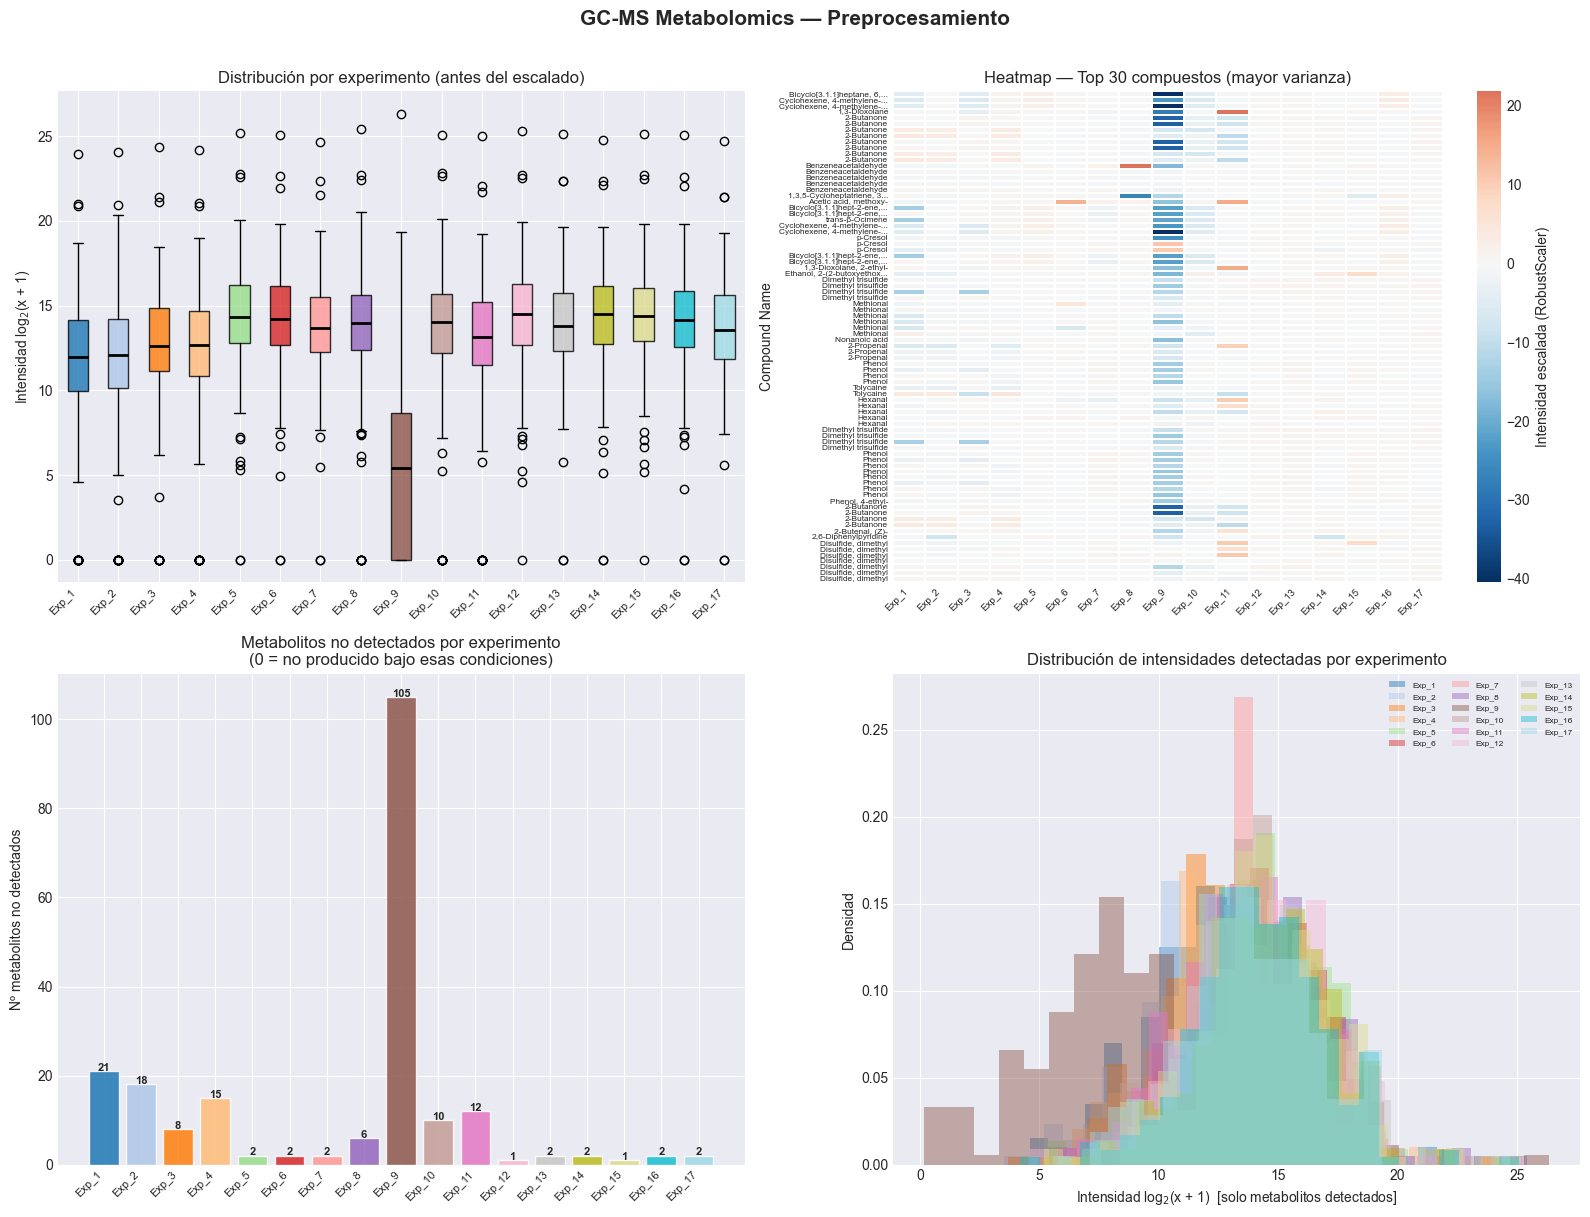

✓ Figura guardada: results/figures/03_preprocessing.png


In [8]:
exp_labels = [col.replace('.CDF', '') for col in exp_cols_sorted]
colors_tab20 = plt.cm.tab20(np.linspace(0, 1, len(exp_cols_sorted)))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('GC-MS Metabolomics — Preprocesamiento', fontsize=15, fontweight='bold', y=1.01)

# ── Plot 1: Boxplot de intensidades log2 por experimento (antes del escalado) ─
ax1 = axes[0, 0]
data_box = [X_log2[col].values for col in exp_cols_sorted]
bp = ax1.boxplot(data_box, patch_artist=True, notch=False,
                 medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors_tab20):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax1.set_xticks(range(1, len(exp_labels) + 1))
ax1.set_xticklabels(exp_labels, rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Intensidad log$_2$(x + 1)')
ax1.set_title('Distribución por experimento (antes del escalado)')

# ── Plot 2: Heatmap de la matriz escalada ────────────────────────────────────
ax2 = axes[0, 1]
top_var_idx = X_scaled.var(axis=1).nlargest(30).index
heatmap_data = X_scaled.loc[top_var_idx]
sns.heatmap(
    heatmap_data, ax=ax2, cmap='RdBu_r', center=0,
    xticklabels=exp_labels,
    yticklabels=[n[:25] + '...' if len(n) > 25 else n for n in heatmap_data.index],
    linewidths=0.3,
    cbar_kws={'label': 'Intensidad escalada (RobustScaler)'}
)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=7)
ax2.set_yticklabels(ax2.get_yticklabels(), fontsize=6)
ax2.set_title('Heatmap — Top 30 compuestos (mayor varianza)')

# ── Plot 3: Metabolitos no detectados (ceros) por experimento ────────────────
ax3 = axes[1, 0]
zeros_per_exp = (X == 0).sum(axis=0)
bars = ax3.bar(range(len(exp_cols_sorted)), zeros_per_exp.values,
               color=colors_tab20, alpha=0.85, edgecolor='white')
ax3.set_xticks(range(len(exp_cols_sorted)))
ax3.set_xticklabels(exp_labels, rotation=45, ha='right', fontsize=8)
ax3.set_ylabel('Nº metabolitos no detectados')
ax3.set_title('Metabolitos no detectados por experimento\n(0 = no producido bajo esas condiciones)')
for bar, val in zip(bars, zeros_per_exp.values):
    if val > 0:
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 str(val), ha='center', fontsize=8, fontweight='bold')

# ── Plot 4: Histograma de distribución log2 por experimento ──────────────────
ax4 = axes[1, 1]
for col, color in zip(exp_cols_sorted, colors_tab20):
    vals = X_log2[col].values
    ax4.hist(vals[vals > 0], bins=25, alpha=0.45,   # excluir 0s del histograma
             label=col.replace('.CDF', ''), color=color, density=True)
ax4.set_xlabel('Intensidad log$_2$(x + 1)  [solo metabolitos detectados]')
ax4.set_ylabel('Densidad')
ax4.set_title('Distribución de intensidades detectadas por experimento')
ax4.legend(fontsize=6, ncol=3, loc='upper right')

plt.tight_layout()
plt.savefig(FIGS / '03_preprocessing.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Figura guardada: results/figures/03_preprocessing.png')

1. ## Distribución por experimento antes del escalado

El boxplot muestra que la mayoría de los experimentos presentan distribuciones de intensidad relativamente comparables, con medianas situadas en rangos próximos y una dispersión similar. Esto sugiere una consistencia global aceptable entre experimentos tras la transformación logarítmica.

Sin embargo, Exp_9 destaca claramente del resto, ya que presenta una mediana mucho más baja, una distribución desplazada hacia intensidades pequeñas y una mayor acumulación de valores cercanos a 0. Este patrón sugiere una menor detección global de metabolitos en dicha condición experimental.

2. ## Heatmap de los 30 compuestos de mayor varianza

El heatmap confirma que la mayor parte de la variabilidad entre experimentos se concentra en un subconjunto reducido de compuestos. En general, los perfiles son relativamente homogéneos, pero Exp_9 vuelve a mostrar un comportamiento diferencial, con predominio de valores bajos en numerosos compuestos de alta variabilidad.

Esto indica que la singularidad de Exp_9 no depende de uno o dos metabolitos aislados, sino de un descenso más generalizado de la señal en múltiples compuestos. Por tanto, este experimento puede considerarse una condición diferenciada dentro del diseño o, alternativamente, un posible caso a revisar desde el punto de vista técnico.

3. ## Metabolitos no detectados por experimento

El gráfico de barras muestra que la mayoría de experimentos presentan muy pocos metabolitos no detectados, normalmente en valores bajos y bastante homogéneos. En cambio, Exp_9 presenta 105 metabolitos no detectados, una cifra muy superior al resto.

Este resultado es especialmente relevante porque en este estudio los valores 0 no se interpretan como error ni como missing values clásicos, sino como metabolitos no detectados bajo esas condiciones experimentales. Por ello, la elevada ausencia de detección en Exp_9 debe interpretarse como un rasgo biológicamente o experimentalmente significativo, no necesariamente como un fallo del dato.

4. ## Distribución de intensidades detectadas

Al considerar únicamente los metabolitos detectados, la mayor parte de los experimentos muestran distribuciones bastante solapadas, con máximos de densidad en intervalos similares. Esto indica que, cuando un metabolito sí es detectado, su rango de intensidades es comparable entre experimentos.

No obstante, Exp_9 presenta una distribución más desplazada hacia intensidades bajas y más extendida hacia la izquierda. Esto refuerza la idea de que, además de detectar menos metabolitos, los que sí detecta tienden a mostrar menor abundancia relativa.

5. ## Conclusión 

Entre los experimentos analizados, Exp_6 muestra uno de los comportamientos más consistentes, con una elevada intensidad media y un número muy reducido de metabolitos no detectados. En conjunto, su perfil sugiere una buena calidad analítica y una cobertura metabolómica adecuada en comparación con el resto de condiciones experimentales.

## Celda 17 — Guardado de matrices preprocesadas

In [9]:
# Añadir columnas de metadatos del cromatógrafo
meta_cols = ['Compound Name', 'Hit 1: Match Factor', 'Match Quality', 'Est. Retention Time (min)']

def add_metadata(matrix, peaks_df, exp_cols):
    df_out = matrix.copy()
    df_out.index.name = 'compound_name'
    df_out = df_out.reset_index()
    df_out.insert(1, 'hit_match_factor', peaks_df['Hit 1: Match Factor'].values)
    df_out.insert(2, 'match_quality',    peaks_df['Match Quality'].values)
    df_out.insert(3, 'retention_time',   peaks_df['Est. Retention Time (min)'].values)
    return df_out

# Guardar X_preprocessed.csv (escalado con RobustScaler)
X_preprocessed_out = add_metadata(X_scaled, peaks_filtered, exp_cols_sorted)
X_preprocessed_out.to_csv(DATA_PROC / 'X_preprocessed.csv', index=False)

# Guardar X_log2.csv (log2 sin escalar — para interpretabilidad)
X_log2_out = add_metadata(X_log2, peaks_filtered, exp_cols_sorted)
X_log2_out.to_csv(DATA_PROC / 'X_log2.csv', index=False)

print('=' * 65)
print('ARCHIVOS GUARDADOS')
print('=' * 65)
print(f'\n✓ data/processed/X_preprocessed.csv')
print(f'   Shape: {X_preprocessed_out.shape}  (compound_name + metadatos + {len(exp_cols_sorted)} experimentos)')
print(f'\n✓ data/processed/X_log2.csv')
print(f'   Shape: {X_log2_out.shape}')

ARCHIVOS GUARDADOS

✓ data/processed/X_preprocessed.csv
   Shape: (279, 21)  (compound_name + metadatos + 17 experimentos)

✓ data/processed/X_log2.csv
   Shape: (279, 21)


## Celda 19 — Resumen del preprocesamiento

In [10]:
print('=' * 65)
print('RESUMEN DEL PREPROCESAMIENTO — NOTEBOOK 03')
print('=' * 65)
print(f'''
CRITERIO DE ENTRADA
  · Fuente                     : peaks_clean.csv ({len(peaks_clean)} picos limpios)
  · Filtro                     : Hit 1: Match Factor ≥ {THRESHOLD}
  · Picos seleccionados        : {len(peaks_filtered)}
  · Picos descartados          : {len(peaks_clean) - len(peaks_filtered)}
  · (La BD solo se usa después para interpretación)

PASO 1 — Matriz de intensidades
  · Shape (picos × experimentos): {X.shape}

PASO 2 — Tratamiento de ceros
  · Ceros en la matriz          : {n_zeros} ({pct_zeros:.1f}%)
  · Decisión                    : SIN imputación — 0 = no detectado bajo esas condiciones

PASO 3 — Transformación log2(x + 1)
  · Media antes   : {mean_before:.3e}  →  Media después  : {mean_after:.4f}
  · Std antes     : {std_before:.3e}  →  Std después    : {std_after:.4f}

PASO 4 — Detección de outliers (Isolation Forest)
  · Experimentos atípicos       : {sum(outlier_mask)} → {outlier_experiments if outlier_experiments else "Ninguno"}

PASO 5 — Escalado robusto (RobustScaler)
  · Media final   : {X_scaled.values.mean():.4f}
  · Mediana final : {np.median(X_scaled.values):.4f}
  · Std final     : {X_scaled.values.std():.4f}

ARCHIVOS DE SALIDA
  · data/processed/X_preprocessed.csv  ({X_preprocessed_out.shape[0]} picos × {len(exp_cols_sorted)} exp + metadatos)
  · data/processed/X_log2.csv          (mismo formato, sin escalar)
  · results/figures/03_preprocessing.png
''')

RESUMEN DEL PREPROCESAMIENTO — NOTEBOOK 03

CRITERIO DE ENTRADA
  · Fuente                     : peaks_clean.csv (372 picos limpios)
  · Filtro                     : Hit 1: Match Factor ≥ 700
  · Picos seleccionados        : 279
  · Picos descartados          : 93
  · (La BD solo se usa después para interpretación)

PASO 1 — Matriz de intensidades
  · Shape (picos × experimentos): (279, 17)

PASO 2 — Tratamiento de ceros
  · Ceros en la matriz          : 211 (4.4%)
  · Decisión                    : SIN imputación — 0 = no detectado bajo esas condiciones

PASO 3 — Transformación log2(x + 1)
  · Media antes   : 2.047e+05  →  Media después  : 12.9645
  · Std antes     : 2.263e+06  →  Std después    : 4.1520

PASO 4 — Detección de outliers (Isolation Forest)
  · Experimentos atípicos       : 1 → ['Exp_9.CDF']

PASO 5 — Escalado robusto (RobustScaler)
  · Media final   : -0.4226
  · Mediana final : 0.0000
  · Std final     : 2.4339

ARCHIVOS DE SALIDA
  · data/processed/X_preprocessed.csv  